# Analisis Sentimen Ulasan E-Commerce Shopee
## Menggunakan Metode Naive Bayes Classifier

**Dataset:** Shopee Product Reviews (Kaggle)  
**Tujuan:** Klasifikasi ulasan ke dalam kelas Positif, Negatif, atau Netral  
**Algoritma:** Multinomial Naive Bayes + TF-IDF Vectorizer  

---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12
print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 2. Load Dataset

In [2]:
# Ganti path sesuai lokasi file CSV Anda dari Kaggle
# Pakai path absolut agar pasti ketemu
CSV_PATH = r'C:\Users\adi35\Downloads\shopee-sentiment-app\shopee-sentiment\dataset\datasetshopee\data.csv'

try:
    df = pd.read_csv(CSV_PATH, encoding='utf-8')
    df = df.rename(columns={'comment': 'review'}) 
    df['sentiment'] = df['rating'].apply(lambda x: 'positif' if x >= 4 else ('negatif' if x <= 2 else 'netral'))
    print(f'✅ Dataset dimuat: {len(df):,} baris × {df.shape[1]} kolom')
    print('\nKolom tersedia:')
    display(df.head())
except FileNotFoundError:
    print('⚠️ File tidak ditemukan, membuat dataset demo ...')
    import sys; sys.path.append('..')
    from ml_model import generate_synthetic_dataset
    df = generate_synthetic_dataset(2000)
    df = df.rename(columns={'comment': 'review'}) 
    print(f'✅ Dataset demo: {len(df):,} baris')
    display(df.head())

✅ Dataset dimuat: 3,020 baris × 4 kolom

Kolom tersedia:


,username,rating,review,sentiment
0,novaentin,5,Sepadan dengan Harga:worth it!\nFitur Terbaik:...,positif
1,mayaanggraeni8888,5,Fitur Terbaik:soundx oke suara jernih\n\nHarga...,positif
2,p*****5,5,Sepadan dengan Harga:spiker\nFitur Terbaik:lum...,positif
3,1uhsg9rxxz,5,Fitur Terbaik:baik\nSepadan dengan Harga:harga...,positif
4,septianflorenzi,5,Fitur Terbaik:mantap harga murah kualitas luma...,positif


## 3. Eksplorasi Data (EDA)

In [3]:
print('=== INFO DATASET ===')
print(df.info())
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== DISTRIBUSI SENTIMEN ===')
print(df['sentiment'].value_counts())

=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 3020 entries, 0 to 3019
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   username   3007 non-null   str  
 1   rating     3020 non-null   int64
 2   review     2704 non-null   str  
 3   sentiment  3020 non-null   str  
dtypes: int64(1), str(3)
memory usage: 94.5 KB
None

=== MISSING VALUES ===
username      13
rating         0
review       316
sentiment      0
dtype: int64

=== DISTRIBUSI SENTIMEN ===
sentiment
positif    2678
negatif     199
netral      143
Name: count, dtype: int64


In [4]:
import pandas as pd
df = pd.read_csv(r'C:\Users\adi35\Downloads\shopee-sentiment-app\shopee-sentiment\dataset\datasetshopee\data.csv', encoding='utf-8')
print(df.columns.tolist())
print(df.head(3))

['username', 'rating', 'comment']
            username  rating  \
0          novaentin       5   
1  mayaanggraeni8888       5   
2            p*****5       5   

                                             comment  
0  Sepadan dengan Harga:worth it!\nFitur Terbaik:...  
1  Fitur Terbaik:soundx oke suara jernih\n\nHarga...  
2  Sepadan dengan Harga:spiker\nFitur Terbaik:lum...  


In [5]:
# Buat kolom sentiment dari rating
df['sentiment'] = df['rating'].apply(lambda x: 'positif' if x >= 4 else ('negatif' if x <= 2 else 'netral'))

print(df['sentiment'].value_counts())
print(df.head(3))


sentiment
positif    2678
negatif     199
netral      143
Name: count, dtype: int64
            username  rating  \
0          novaentin       5   
1  mayaanggraeni8888       5   
2            p*****5       5   

                                             comment sentiment  
0  Sepadan dengan Harga:worth it!\nFitur Terbaik:...   positif  
1  Fitur Terbaik:soundx oke suara jernih\n\nHarga...   positif  
2  Sepadan dengan Harga:spiker\nFitur Terbaik:lum...   positif  


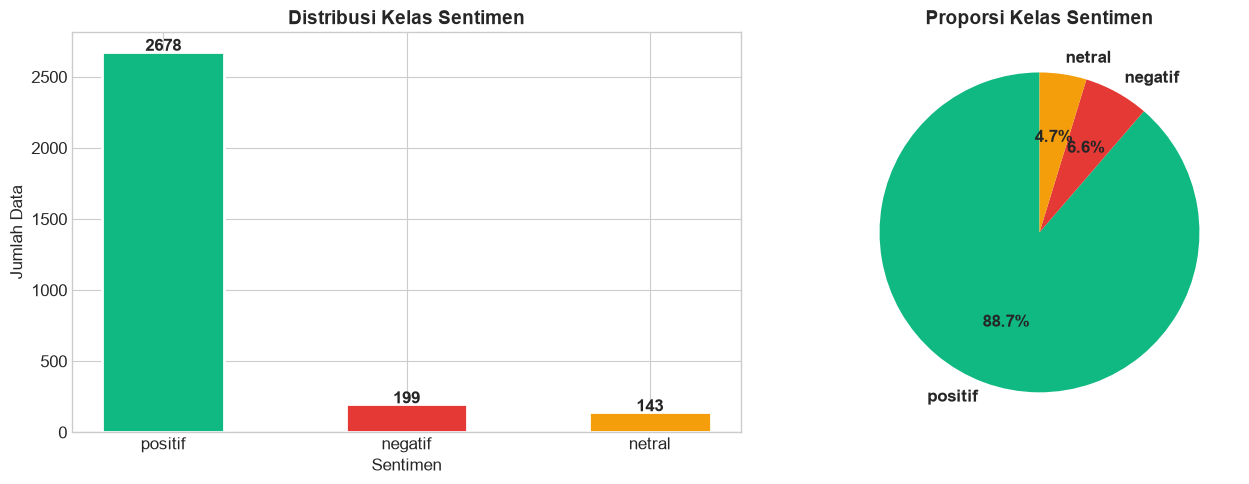

📊 Chart distribusi disimpan


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi sentimen - Bar
counts = df['sentiment'].value_counts()
colors = ['#10B981', '#E53935', '#F59E0B']
axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], width=0.5, edgecolor='white', linewidth=2)
axes[0].set_title('Distribusi Kelas Sentimen', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Data')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

# Distribusi sentimen - Pie
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors[:len(counts)], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Kelas Sentimen', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../static/img/distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart distribusi disimpan')

In [7]:
import os
os.makedirs('../static/img', exist_ok=True)
print("✅ Folder static/img berhasil dibuat")

✅ Folder static/img berhasil dibuat


## 4. Preprocessing Teks

In [8]:
import sys; sys.path.append('..')
from ml_model import preprocess_text, STOPWORDS_ID

print(f'Jumlah stopwords: {len(STOPWORDS_ID)}')
print('\nContoh preprocessing:')

contoh = [
    'Barang datang CEPAT banget!! Kualitas TOP 👍👍 recommended seller',
    'Sangat kecewa, barang tidak sesuai foto dan rusak...',
]
for c in contoh:
    print(f'  Input  : {c}')
    print(f'  Output : {preprocess_text(c)}')
    print()

Jumlah stopwords: 63

Contoh preprocessing:
  Input  : Barang datang CEPAT banget!! Kualitas TOP 👍👍 recommended seller


NameError: name 'simple_stemmer' is not defined

In [ ]:
# Pastikan kolom sudah benar
if 'comment' in df.columns:
    df = df.rename(columns={'comment': 'review'})
    
print(df.columns.tolist())

['username', 'rating', 'review', 'sentiment']


In [ ]:
print(df.columns.tolist())

['username', 'rating', 'review', 'sentiment']


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [ ]:
print('🔧 Memproses seluruh dataset ...')
df['clean_text'] = df['review'].apply(preprocess_text)
df['text_length'] = df['clean_text'].str.split().str.len()

# Filter teks terlalu pendek
df = df[df['clean_text'].str.len() > 5].reset_index(drop=True)
print(f'✅ Selesai. Dataset tersisa: {len(df):,} baris')
display(df[['review', 'clean_text', 'sentiment']].head(5))

🔧 Memproses seluruh dataset ...
✅ Selesai. Dataset tersisa: 2,667 baris


,review,clean_text,sentiment
0,Sepadan dengan Harga:worth it!\nFitur Terbaik:...,pad harga worth fitur baik lucu bgt mic cil ri...,positif
1,Fitur Terbaik:soundx oke suara jernih\n\nHarga...,fitur baik soundx oke suara jernih harga murce...,positif
2,Sepadan dengan Harga:spiker\nFitur Terbaik:lum...,pad harga spiker fitur baik lumay buat har har...,positif
3,Fitur Terbaik:baik\nSepadan dengan Harga:harga...,fitur baik pad harga harga murah kualitas bagus,positif
4,Fitur Terbaik:mantap harga murah kualitas luma...,fitur baik mantap harga murah kualitas lumay p...,positif


In [ ]:
print(type(df))
print(df.columns.tolist())
print(df.shape)

<class 'pandas.DataFrame'>
['username', 'rating', 'review', 'sentiment', 'clean_text', 'text_length']
(2667, 6)


In [ ]:
df = df.rename(columns={'comment': 'review'})
print(df.columns.tolist())

['username', 'rating', 'review', 'sentiment', 'clean_text', 'text_length']


In [ ]:
# Cek kolom saat ini
print("Kolom sekarang:", df.columns.tolist())

# Rename jika masih 'comment'
if 'comment' in df.columns:
    df = df.rename(columns={'comment': 'review'})
    print("✅ Berhasil rename 'comment' → 'review'")

print("Kolom setelah rename:", df.columns.tolist())

Kolom sekarang: ['username', 'rating', 'review', 'sentiment', 'clean_text', 'text_length']
Kolom setelah rename: ['username', 'rating', 'review', 'sentiment', 'clean_text', 'text_length']


In [ ]:
# Cek semua nama kolom
print(df.columns.tolist())

# Rename kolom agar sesuai dengan kode yang sudah ada
df = df.rename(columns={'comment': 'review'})
print("✅ Kolom berhasil direname")
print(df.columns.tolist())

['username', 'rating', 'review', 'sentiment', 'clean_text', 'text_length']
✅ Kolom berhasil direname
['username', 'rating', 'review', 'sentiment', 'clean_text', 'text_length']


In [ ]:
X = df['clean_text'].values
y = df['sentiment'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Label encoder mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)
X_vec = tfidf.fit_transform(X)
print(f'\nUkuran matriks TF-IDF: {X_vec.shape}')
print(f'Ukuran kosakata: {len(tfidf.vocabulary_):,} token')

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f'Data latih : {X_train.shape[0]:,}')
print(f'Data uji   : {X_test.shape[0]:,}')

Label encoder mapping: {'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}

Ukuran matriks TF-IDF: (2667, 3371)
Ukuran kosakata: 3,371 token
Data latih : 2,133
Data uji   : 534


## 6. Training Naive Bayes

In [ ]:
model = MultinomialNB(alpha=0.5)  # Laplace smoothing
model.fit(X_train, y_train)
print('✅ Model berhasil dilatih!')

y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
prec   = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1     = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'\n{'='*40}')
print(f'  Akurasi   : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f} ({prec*100:.2f}%)')
print(f'  Recall    : {rec:.4f} ({rec*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f} ({f1*100:.2f}%)')
print('='*40)

✅ Model berhasil dilatih!

  Akurasi   : 0.8951 (89.51%)
  Precision : 0.8390 (83.90%)
  Recall    : 0.8951 (89.51%)
  F1-Score  : 0.8582 (85.82%)


## 7. Evaluasi & Visualisasi

In [ ]:
print('📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

📋 Classification Report:
              precision    recall  f1-score   support

     negatif       0.67      0.26      0.37        39
      netral       0.00      0.00      0.00        27
     positif       0.90      1.00      0.95       468

    accuracy                           0.90       534
   macro avg       0.52      0.42      0.44       534
weighted avg       0.84      0.90      0.86       534



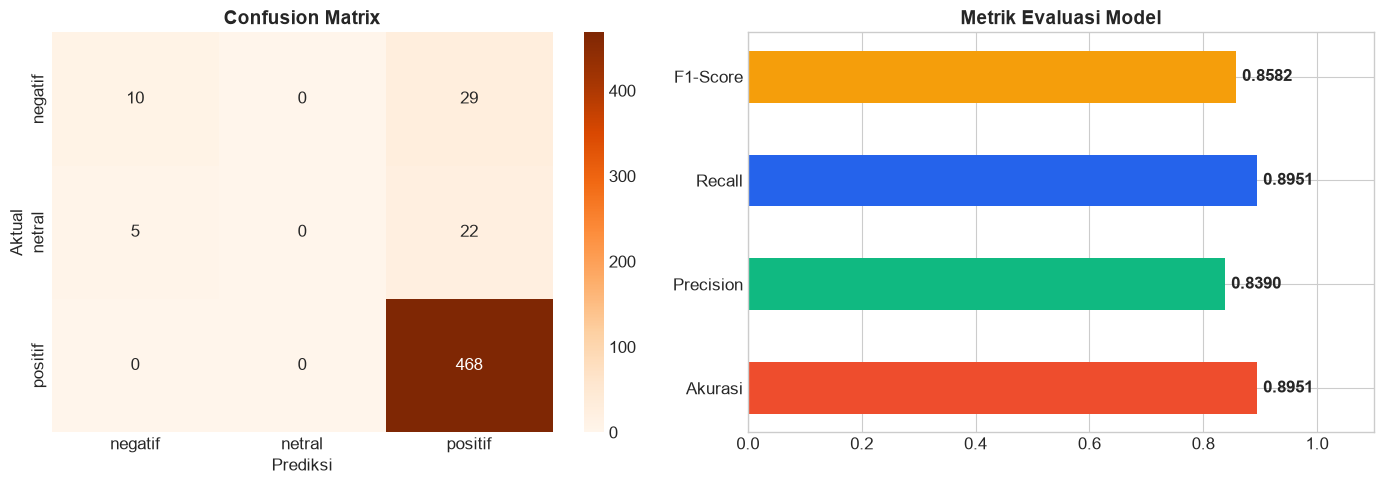

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Metrik Bar
metric_names  = ['Akurasi', 'Precision', 'Recall', 'F1-Score']
metric_values = [acc, prec, rec, f1]
bars = axes[1].barh(metric_names, metric_values,
                     color=['#EE4D2D','#10B981','#2563EB','#F59E0B'],
                     height=0.5)
axes[1].set_xlim(0, 1.1)
axes[1].set_title('Metrik Evaluasi Model', fontsize=14, fontweight='bold')
for bar, val in zip(bars, metric_values):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../static/img/evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()

🔁 Menjalankan 5-Fold Cross Validation ...

Hasil per fold: ['0.8989', '0.8933', '0.8893', '0.9006', '0.8893']
Rata-rata     : 0.8943 ± 0.0047


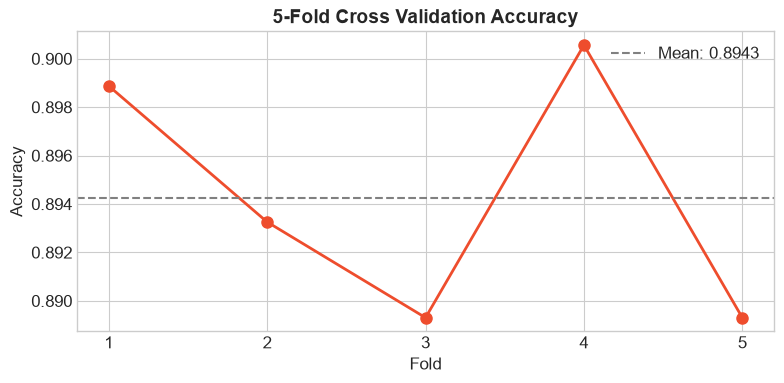

In [ ]:
# Cross-Validation 5-Fold
print('🔁 Menjalankan 5-Fold Cross Validation ...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(MultinomialNB(alpha=0.5), X_vec, y_enc, cv=cv, scoring='accuracy')

print('\nHasil per fold:', [f'{s:.4f}' for s in cv_scores])
print(f'Rata-rata     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores, 'o-', color='#EE4D2D', linewidth=2, markersize=8)
plt.axhline(cv_scores.mean(), color='gray', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.title('5-Fold Cross Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Fold'); plt.ylabel('Accuracy')
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()

## 8. Simpan Model

In [ ]:
import joblib, os
os.makedirs('../models', exist_ok=True)

joblib.dump(model,  '../models/naive_bayes.pkl')
joblib.dump(tfidf,  '../models/tfidf_vectorizer.pkl')
joblib.dump(le,     '../models/label_encoder.pkl')
joblib.dump(df,     '../models/dataframe.pkl')
print('✅ Model dan artefak berhasil disimpan ke folder models/')

✅ Model dan artefak berhasil disimpan ke folder models/


## 9. Uji Prediksi Manual

In [ ]:
def predict_manual(text):
    cleaned = preprocess_text(text)
    vec     = tfidf.transform([cleaned])
    pred    = model.predict(vec)[0]
    proba   = model.predict_proba(vec)[0]
    label   = le.inverse_transform([pred])[0]
    print(f'  Teks     : {text}')
    print(f'  Cleaned  : {cleaned}')
    print(f'  Sentimen : {label.upper()}')
    for cls, p in zip(le.classes_, proba):
        bar = '█' * int(p * 30)
        print(f'  {cls:10s}: {bar} {p:.1%}')
    print()

predict_manual('Barang cepat sampai, kualitas bagus, penjual ramah! Sangat puas!')
predict_manual('Kecewa banget, barang tidak sesuai gambar dan rusak parah.')
predict_manual('Barang oke, pengiriman normal, sesuai harga yang dibayar.')

  Teks     : Barang cepat sampai, kualitas bagus, penjual ramah! Sangat puas!
  Cleaned  : barang cepat sampa kualitas bagus njual ramah puas
  Sentimen : POSITIF
  negatif   :  0.2%
  netral    :  0.1%
  positif   : █████████████████████████████ 99.7%

  Teks     : Kecewa banget, barang tidak sesuai gambar dan rusak parah.
  Cleaned  : cewa barang sua gambar rusak parah
  Sentimen : POSITIF
  negatif   : █████ 18.6%
  netral    : █ 3.9%
  positif   : ███████████████████████ 77.4%

  Teks     : Barang oke, pengiriman normal, sesuai harga yang dibayar.
  Cleaned  : barang oke ngirim normal sua harga dibayar
  Sentimen : POSITIF
  negatif   :  0.8%
  netral    :  0.6%
  positif   : █████████████████████████████ 98.6%



In [ ]:
print(preprocess_text("tidak sesuai kecewa rusak"))
print(preprocess_text("Sangat kecewa dengan produk ini. Barang yang datang tidak sesuai foto"))

sua cewa rusak
cewa produk barang datang sua foto


In [ ]:
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True) * 100)

sentiment
positif    2338
negatif     195
netral      134
Name: count, dtype: int64
sentiment
positif    87.664042
negatif     7.311586
netral      5.024372
Name: proportion, dtype: float64


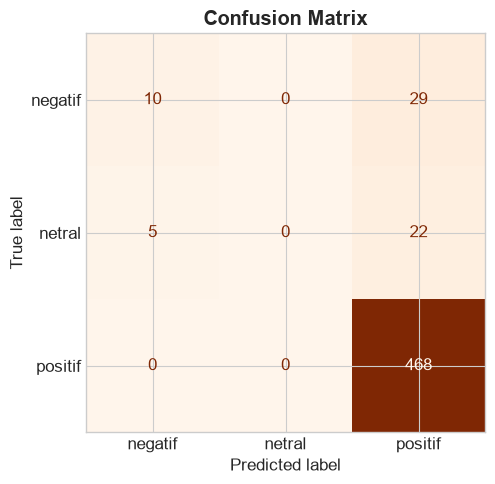

✅ confusion_matrix.png tersimpan


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_test),
    le.inverse_transform(y_pred),
    ax=ax,
    colorbar=False,
    cmap='Oranges'
)
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../static/img/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ confusion_matrix.png tersimpan")